In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_DIR = Path(
    r"D:\Veda Internship\Sakshi\Super_Store_DataCleaning"
    r"\OTT_Streaming_Content_Trend_Analysis_Day31"
    r"\Day3_OTT_Content_Analysis"
)

CHART_DIR = PROJECT_DIR / "charts"
CHART_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = Path(
    r"D:\Veda Internship\Sakshi\Super_Store_DataCleaning"
    r"\OTT_Streaming_Content_Trend_Analysis_Day31"
    r"\Day1_OTT_Content_Analysis\Dataset\netflix_titles.csv"
)

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

display(df.head())


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\traitlets\config\application.py", line 1082, in launch_instance
    app.start()
  File "C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\ipykernel\kernelapp.py", line 807,

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\traitlets\config\application.py", line 1082, in launch_instance
    app.start()
  File "C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\ipykernel\kernelapp.py", line 807,

AttributeError: _ARRAY_API not found

Dataset loaded successfully!
Shape: (6234, 12)
Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...
2,70234439,TV Show,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,"September 8, 2018",2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob..."
3,80058654,TV Show,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,"September 8, 2018",2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...


In [2]:
df.columns = df.columns.str.strip()

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

df["date_added"] = pd.to_datetime(
    df["date_added"].astype("string").str.strip(),
    errors="coerce"
)

df["year_added"] = df["date_added"].dt.year

df["duration_value"] = pd.to_numeric(
    df["duration"].astype("string").str.extract(r"(\d+)")[0],
    errors="coerce"
)

df["primary_genre"] = (
    df["listed_in"].fillna("Unknown").str.split(",").str[0].str.strip()
)

df["primary_country"] = (
    df["country"].fillna("Unknown").str.split(",").str[0].str.strip()
)

print("Data preparation completed!")
display(df.head())

Data preparation completed!


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,duration_value,primary_genre,primary_country
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China",2019-09-09,2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...,2019.0,90,Children & Family Movies,United States
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,2016-09-09,2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...,2016.0,94,Stand-Up Comedy,United Kingdom
2,70234439,TV Show,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,2018-09-08,2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob...",2018.0,1,Kids' TV,United States
3,80058654,TV Show,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,2018-09-08,2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...,2018.0,1,Kids' TV,United States
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,2017-09-08,2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...,2017.0,99,Comedies,United States


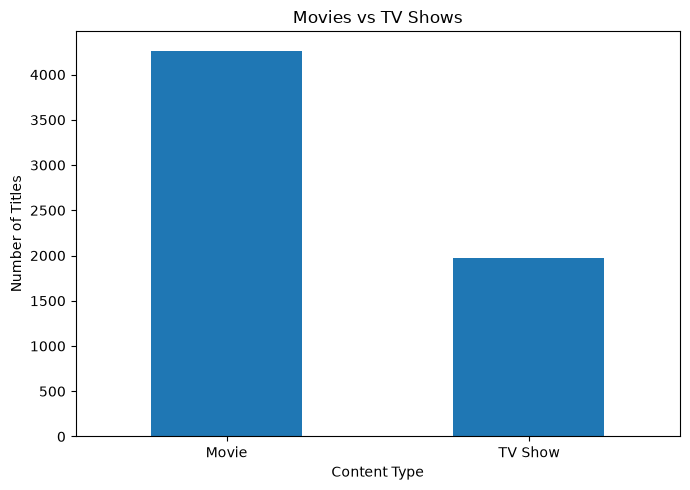

In [3]:
# Chart 1 — Movies vs TV Shows
df["type"].value_counts().plot(
    kind="bar",
    figsize=(7, 5),
    rot=0
)

plt.title("Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.savefig(CHART_DIR / "01_content_type.png", dpi=150)
plt.show()


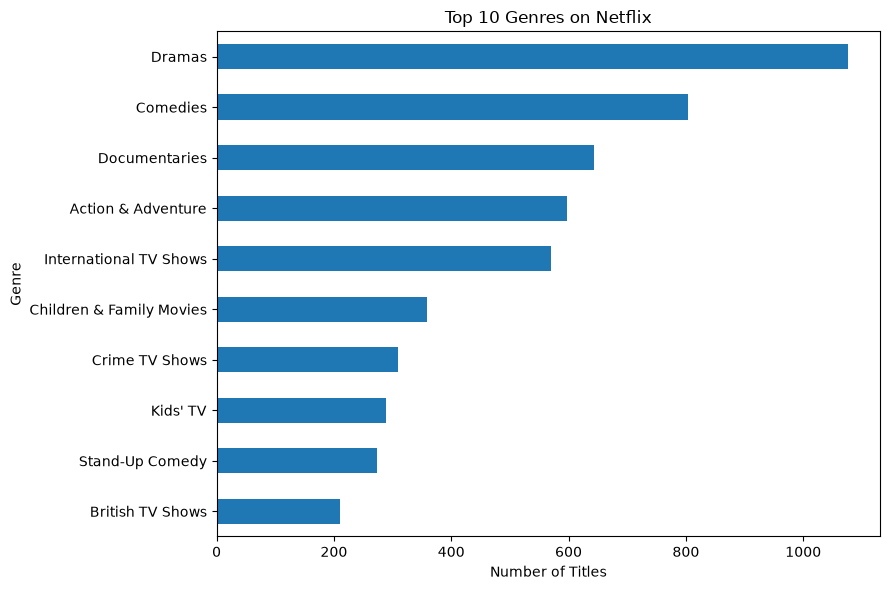

In [4]:
# Chart 2 — Top 10 genres
df["primary_genre"].value_counts().head(10).sort_values().plot(
    kind="barh",
    figsize=(9, 6)
)

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.tight_layout()
plt.savefig(CHART_DIR / "02_top_genres.png", dpi=150)
plt.show()

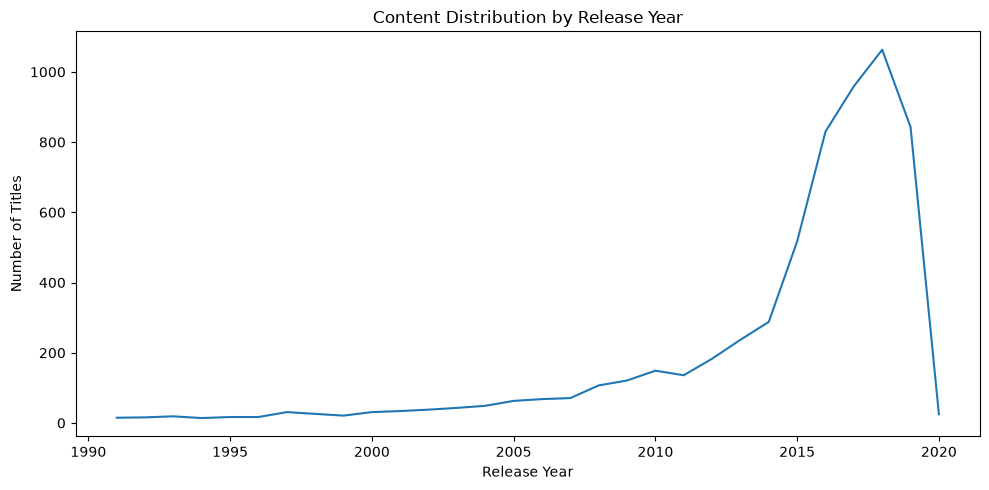

In [5]:
#Chart 3 — Release-year trend
df["release_year"] = pd.to_numeric(
    df["release_year"], errors="coerce"
)

df.groupby("release_year").size().sort_index().tail(30).plot(
    figsize=(10, 5)
)

plt.title("Content Distribution by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.savefig(CHART_DIR / "03_release_year_trend.png", dpi=150)
plt.show()

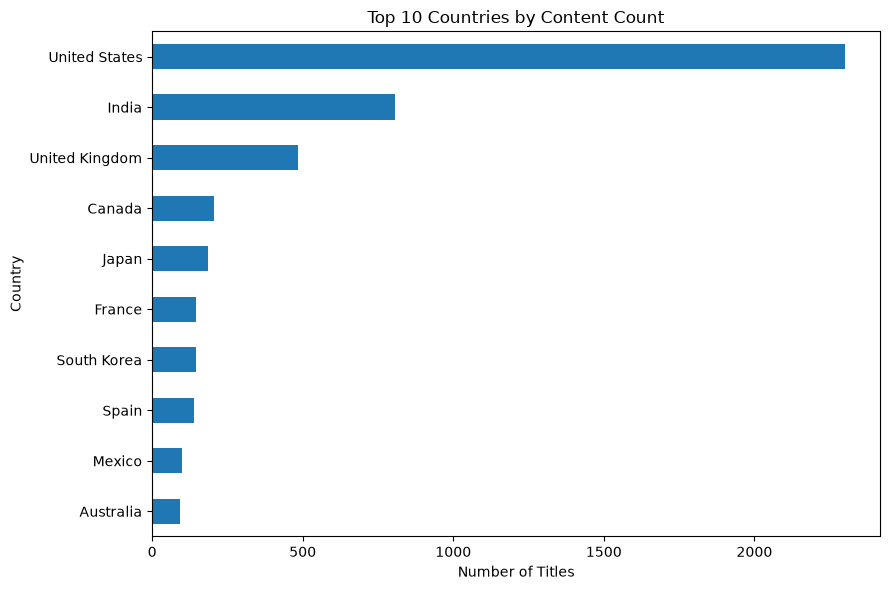

In [6]:
#Chart 4 — Top 10 countries
country_counts = (
    df.loc[df["primary_country"] != "Unknown", "primary_country"]
    .value_counts()
    .head(10)
    .sort_values()
)

country_counts.plot(kind="barh", figsize=(9, 6))

plt.title("Top 10 Countries by Content Count")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig(CHART_DIR / "04_top_countries.png", dpi=150)
plt.show()

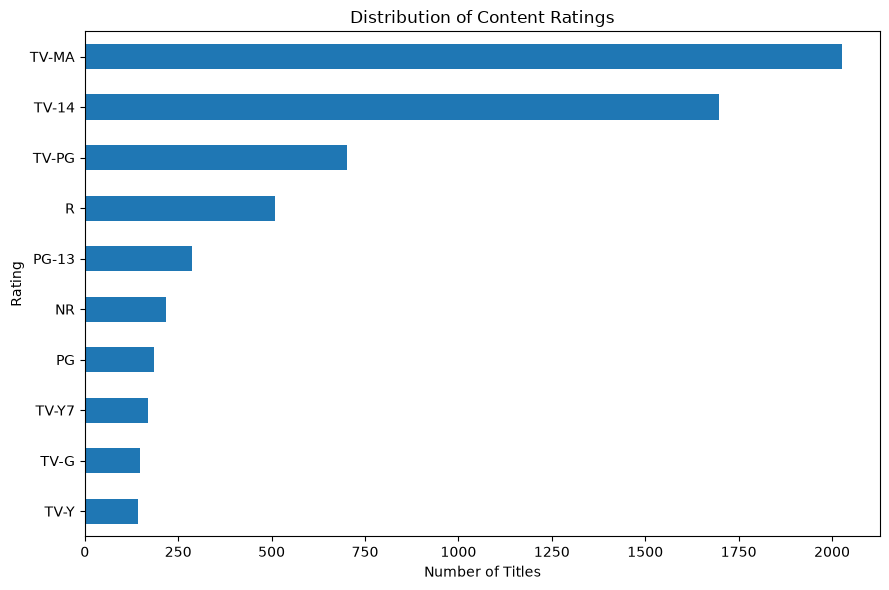

In [7]:
#Chart 5 — Content ratings
df["rating"].fillna("Unknown").value_counts().head(10).sort_values().plot(
    kind="barh",
    figsize=(9, 6)
)

plt.title("Distribution of Content Ratings")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")
plt.tight_layout()
plt.savefig(CHART_DIR / "05_content_ratings.png", dpi=150)
plt.show()

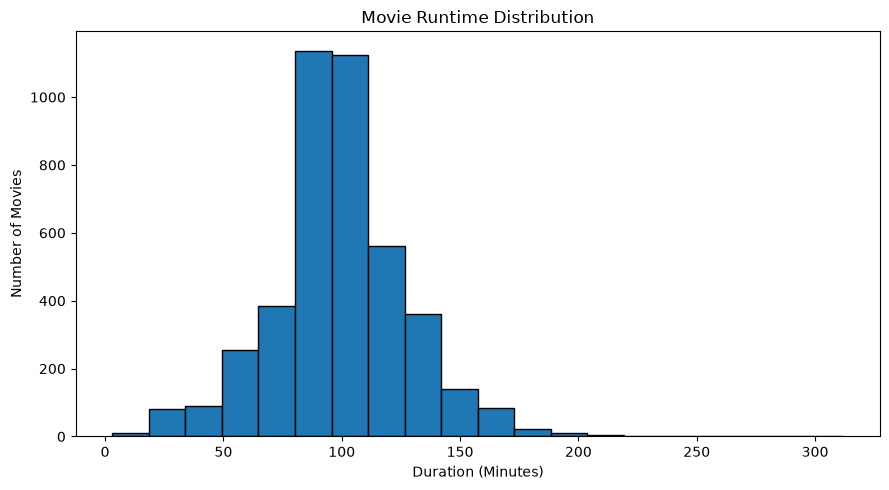

In [8]:
#Chart 6 — Movie duration distribution
movie_duration = df.loc[
    df["type"] == "Movie", "duration_value"
].dropna()

movie_duration = movie_duration[movie_duration.between(1, 400)]

plt.figure(figsize=(9, 5))
plt.hist(movie_duration, bins=20, edgecolor="black")

plt.title("Movie Runtime Distribution")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.savefig(CHART_DIR / "06_movie_duration.png", dpi=150)
plt.show()

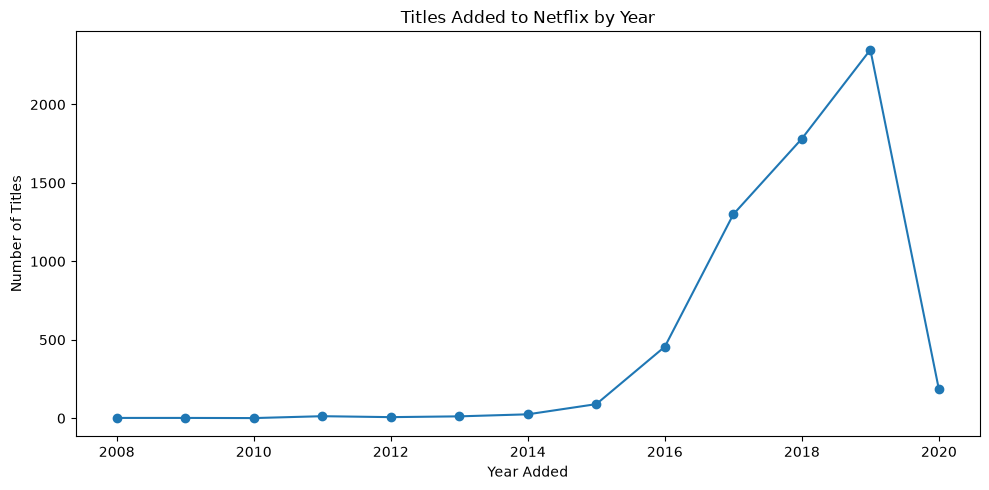

In [9]:
# Chart 7: seventh chart — titles added by year
df.groupby("year_added").size().sort_index().plot(
    figsize=(10, 5), marker="o"
)

plt.title("Titles Added to Netflix by Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.savefig(CHART_DIR / "07_titles_added_by_year.png", dpi=150)
plt.show()

In [10]:
print("TOTAL TITLES:", len(df))

print("\nCONTENT TYPE:")
print(df["type"].value_counts())

print("\nTOP 5 GENRES:")
print(df["primary_genre"].value_counts().head(5))

print("\nTOP 5 COUNTRIES:")
print(df["primary_country"].value_counts().head(5))

print("\nTOP 5 RATINGS:")
print(df["rating"].value_counts().head(5))

print("\nMEDIAN MOVIE DURATION:")
print(round(movie_duration.median(), 2), "minutes")

print("\nTOP 5 RELEASE YEARS:")
print(df["release_year"].value_counts().head(5))

TOTAL TITLES: 6234

CONTENT TYPE:
type
Movie      4265
TV Show    1969
Name: count, dtype: int64

TOP 5 GENRES:
primary_genre
Dramas                    1077
Comedies                   803
Documentaries              644
Action & Adventure         597
International TV Shows     570
Name: count, dtype: int64

TOP 5 COUNTRIES:
primary_country
United States     2302
India              808
United Kingdom     483
Unknown            476
Canada             206
Name: count, dtype: int64

TOP 5 RATINGS:
rating
TV-MA    2027
TV-14    1698
TV-PG     701
R         508
PG-13     286
Name: count, dtype: int64

MEDIAN MOVIE DURATION:
98.0 minutes

TOP 5 RELEASE YEARS:
release_year
2018    1063
2017     959
2019     843
2016     830
2015     517
Name: count, dtype: int64


### Insight 1: Content Type and Genre Analysis

The dataset contains **6,234 titles**, including 4,265 Movies and 1,969 TV Shows. Movies account for approximately **68.4%** of the catalog, while TV Shows account for **31.6%**. Dramas are the most common primary genre with 1,077 titles, followed by Comedies (803) and Documentaries (644).

**Business Recommendation:** The content acquisition team should maintain a balanced portfolio of movies and TV shows. Since Dramas and Comedies have a strong presence in the catalog, the team should evaluate their actual viewership and audience engagement before acquiring more titles. Documentaries and other genres can be tested to identify additional content opportunities.

### Insight 2: Country-Wise Content Distribution

The United States contributes the highest number of titles, with **2,302 titles**, followed by India with **808 titles** and the United Kingdom with 483 titles. The United States accounts for approximately 36.9% of the dataset, while India accounts for approximately 13.0%. Additionally, 476 titles have an unknown country entry, indicating an opportunity to improve metadata quality.

**Business Recommendation:** The platform should investigate regional audience demand and language preferences, particularly in markets such as India. It should also improve missing country metadata to support more reliable regional analysis. Content investment decisions should be validated using regional viewing hours, subscriber engagement, and acquisition costs.

### Insight 3: Release-Year Trends, Ratings, and Movie Duration

The highest number of titles in the dataset was released in **2018 (1,063 titles)**, followed by 2017 (959) and 2019 (843). TV-MA is the most common content rating with 2,027 titles, followed by TV-14 with 1,698 titles. The median movie duration is **98 minutes**, suggesting that a typical movie in this dataset is around 1 hour and 38 minutes long.

**Business Recommendation:** The content team should investigate the strong representation of titles released between 2016 and 2019 and compare it with more recent releases. It should also evaluate content-rating preferences across audience segments and test movies with different runtimes. Actual viewing and completion data should guide future acquisition decisions.